In [1]:
import inspect
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm import tqdm
def minimize_evo(function, population_size, reproduction_size, n_generations, mutation_rate, mutation_var, expected_min, min_eps = 10**(-3), start_mean = 0, start_std = 1, probs_eps = 10**(-3)):
    n_args = len(inspect.signature(function).parameters)
    #normal pop init
    population = np.random.normal(start_mean, start_std, (population_size, n_args))
    vals = np.array(list(map(lambda args: function(*args), population)))
    population = np.hstack([population, vals.reshape(-1,1)])
    best_specimens = [population[np.argmin(population[:,-1]), :-1]]
    min_values = [population[np.argmin(population[:,-1]), -1]]
    for i in range(n_generations):
        #calculate reproduction probabilities
        probs = -population[:,-1]
        probs -= np.min(probs)
        probs += probs_eps
        probs /= np.sum(probs)
        new_gen = []
        #reproduction loop
        for j in range(reproduction_size//2):
            #sample from calculated probability dist
            idx1 = np.random.choice(population_size, p=probs)
            idx2 = np.random.choice(population_size, p=probs)
            specimen1 = population[idx1,:-1]
            specimen2 = population[idx2,:-1]
            #cross
            child1, child2 = cross_2_specimen(specimen1, specimen2)
            #mutate
            child1 = mutate_specimen(child1, mutation_rate, mutation_var)
            child2 = mutate_specimen(child2, mutation_rate, mutation_var)
            #append
            new_gen.append(child1)
            new_gen.append(child2)
        #merge pops
        new_pop = np.concatenate([population[:,:-1], new_gen])
        #calculate values (some redundancy idc)
        vals = np.array(list(map(lambda args: function(*args), new_pop)))
        population = np.hstack([new_pop, vals.reshape(-1,1)])
        #select best fitted specimens
        population = population[np.argsort(population[:,-1])]
        population = population[:population_size]
        #save the best one (array is already sorted so it is on idx 0)
        best_specimens.append(population[0,:-1])
        min_values.append(population[0,-1])
        curr_min = min_values[-1]
        if abs(curr_min - expected_min) < min_eps:
            break
    return best_specimens, min_values



def cross_2_specimen(specimen1, specimen2):
    if len(specimen1) != len(specimen2):
        raise ValueError("Specimens must have same length")
    sep_idx = np.random.randint(len(specimen1))
    child1 = np.concatenate([specimen1[:sep_idx], specimen2[sep_idx:]])
    child2 = np.concatenate([specimen2[:sep_idx], specimen1[sep_idx:]])
    return child1, child2

def mutate_specimen(specimen, mutation_rate, mutation_var):
    n_mutations = np.random.binomial(len(specimen), mutation_rate)
    mutation_idxs = np.random.choice(len(specimen), size=n_mutations, replace=False)
    mutations = np.random.normal(0, mutation_var, (n_mutations))
    for i, idx in enumerate(mutation_idxs):
        specimen[idx] += mutations[i]
    return specimen






In [2]:
def threesquares(x,y,z):
    return x**2 + y**2 + 2*z**2
def fiveDrastrigin(a, b, c, d, e):
    args = np.array([a, b, c, d, e])
    A = 10
    tosum = args**2 - A*np.cos(2*np.pi*args)
    return 5*A + np.sum(tosum)

# Suma kwadratów

In [50]:
for i in range(10):
    _, min_values = minimize_evo(threesquares, 200, 100, 200, 1e-1, 2e-1, 0, 10e-3, 100, 100)
    print(len(min_values))

85
127
72
57
95
54
110
190
54
69


# Rastrigin

In [52]:
for i in range(10):
    _, min_values = minimize_evo(fiveDrastrigin, 200, 100, 200, 1e-1, 0.6, 0, 10e-3, 100, 100)
    print(len(min_values))

176
142
201
128
175
144
153
163
177
189


# Rastrigin grid search (mutation_rate i mutation_var)

In [18]:
def evaluate_combination(args):
    i, j, mutation_rate, mutation_var = args
    convergence = 0
    found = 0
    for _ in range(5):
        _, min_value = minimize_evo(
            fiveDrastrigin, 500, 500, 300, mutation_rate, mutation_var, 0, 1e-3, 0, 100
        )
        convergence += len(min_value)
        found += min_value[-1]
    return i, j, convergence / 5, found / 5

# Prepare the grid
mutation_rates = np.linspace(0.01, 0.5, 50)
mutation_vars = np.linspace(0.04, 2, 50)

# Generate all (i, j) combinations
task_list = [
    (i, j, mutation_rates[i], mutation_vars[j])
    for i in range(50)
    for j in range(50)
]

# Results arrays
convergence_times = np.zeros((50, 50))
found_minima = np.zeros((50, 50))

# Run in parallel
with mp.Pool(11) as pool:
    for i, j, convergence, found in tqdm(pool.imap_unordered(evaluate_combination, task_list), total=len(task_list)):
        convergence_times[i, j] = convergence
        found_minima[i, j] = found

100%|██████████| 2500/2500 [1:26:32<00:00,  2.08s/it]


Text(0, 0.5, 'mutation rate')

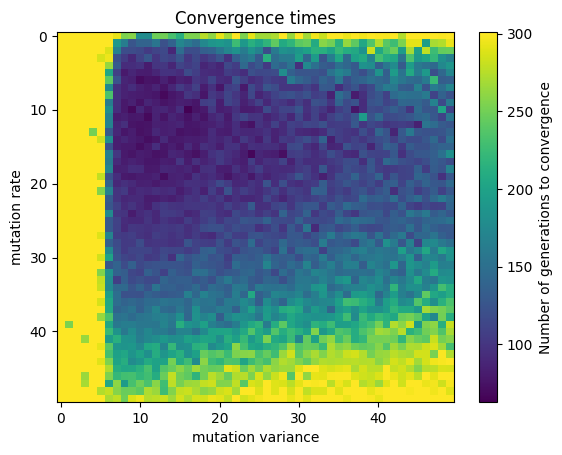

In [19]:
plt.imshow(convergence_times, cmap='viridis', aspect='auto')
plt.colorbar(label = 'Number of generations to convergence')
plt.title('Convergence times')
plt.xlabel('mutation variance')
plt.ylabel('mutation rate')

Text(0, 0.5, 'mutation rate')

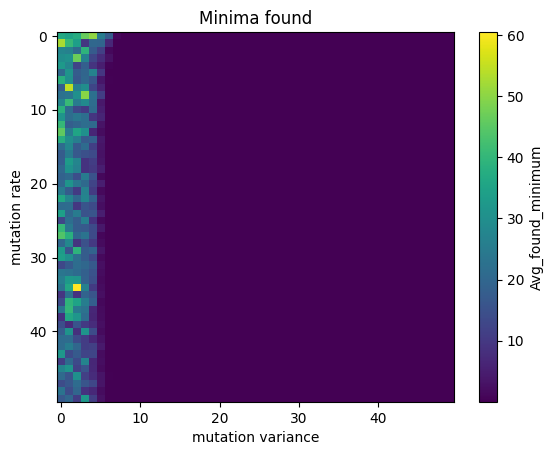

In [20]:
plt.imshow(found_minima, cmap='viridis', aspect='auto')
plt.colorbar(label = 'Avg_found_minimum')
plt.title('Minima found')
plt.xlabel('mutation variance')
plt.ylabel('mutation rate')